# day-04-context-windows — worked solutions & answer key

Solutions to the exercises in [`../lesson.ipynb`](../lesson.ipynb), plus the self-check answer key. **Try each exercise yourself first** — the value is in the attempt, not the answer.

In [13]:
# ---- Solution 1 ----
def budget(W, sys_tokens, answer_reserve):
    return W - sys_tokens - answer_reserve
print("S1:", budget(8192, 300, 800), "tokens for history + docs")

S1: 7092 tokens for history + docs


S2: log-log slope = 2.00  (2.0 == perfectly quadratic)


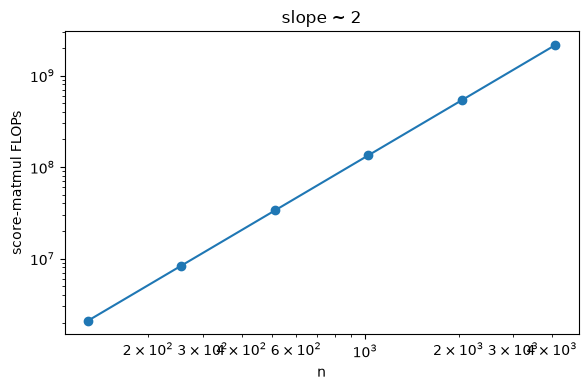

In [14]:
# ---- Solution 2 ----
def attention_flops(n, d=64):
    dt, mem = attention_cost(n, d)
    flops = 2 * n * n * d          # Q@K.T
    return flops

ns = np.array([128, 256, 512, 1024, 2048, 4096])
fl = np.array([attention_flops(n) for n in ns])
slope = np.polyfit(np.log(ns), np.log(fl), 1)[0]
print(f"S2: log-log slope = {slope:.2f}  (2.0 == perfectly quadratic)")
plt.figure(figsize=(6,4)); plt.loglog(ns, fl, marker="o")
plt.xlabel("n"); plt.ylabel("score-matmul FLOPs"); plt.title("slope ~ 2"); plt.tight_layout(); plt.show()

In [15]:
# ---- Solution 3 ----
import re
def truncate_smart(system, turns, W):
    pinned = [t for t in turns if re.search(r'\b[A-Z]{2,}[:=]', t)]
    rest   = [t for t in turns if t not in pinned]
    budget_ = W - ntok(system) - sum(ntok(t) for t in pinned)
    kept, total = [], 0
    for t in reversed(rest):
        if total + ntok(t) > budget_: break
        kept.append(t); total += ntok(t)
    return [system] + pinned + list(reversed(kept))

demo = [f"USER: KEY={i}" if i in (1,) else f"USER: turn {i} chit chat about the weather and stuff" for i in range(1,30)]
out = truncate_smart(SYSTEM, demo, W=400)
print("S3: pinned kept?", any("KEY=" in m for m in out), "| total msgs:", len(out))

S3: pinned kept? True | total msgs: 30


In [16]:
# ---- Solution 4 ----
corpus_words = set(corpus.split())
def grounded_rate(prompt, n_samples=200):
    g = 0
    for s in range(n_samples):
        out = generate(prompt, n=10, seed=s).split()[2:]  # drop the 2 prompt-seed words
        g += all(w in corpus_words for w in out)
    return g / n_samples

print(f"S4: grounded rate in-distribution  = {grounded_rate('the payments service'):.2f}")
print(f"S4: grounded rate out-of-dist      = {grounded_rate('the billing service'):.2f}")
print("    (all words happen to be in-vocab; 'grounded' here just means 'plausible shapes' - "
      "real grounding needs fact checking, not vocab membership)")

S4: grounded rate in-distribution  = 1.00
S4: grounded rate out-of-dist      = 1.00
    (all words happen to be in-vocab; 'grounded' here just means 'plausible shapes' - real grounding needs fact checking, not vocab membership)


In [17]:
# ---- Solution 5 ----
answer_chunk = 7
n_chunks = 20
def expected_recall(pos):
    return recall_prob(pos / (n_chunks - 1))
print(f"S5 (a) in place  pos 7 : {expected_recall(7):.2f}")
print(f"S5 (b) moved to  pos 0 : {expected_recall(0):.2f}")
print(f"S5 (c) moved to  pos 19: {expected_recall(19):.2f}")

S5 (a) in place  pos 7 : 0.57
S5 (b) moved to  pos 0 : 0.75
S5 (c) moved to  pos 19: 1.00


In [18]:
# ---- Solution 6 ----
def fake_summarize_v2(messages, max_age_keep=10):
    recent_enough = messages[-max_age_keep:]
    facts = [m.split('ASSISTANT: ')[-1][:80] for m in recent_enough if 'KEY=' in m or 'retries' in m]
    return "SUMMARY (older than 10 turns dropped entirely): " + " | ".join(facts or ["(nothing kept)"])

print("S6:", fake_summarize_v2([f"ASSISTANT: turn {i}, KEY={i}" for i in range(1, 40)]))
print("    A question about turn 3's KEY is now unanswerable: turn 3 is older than the last 10,")
print("    it was not a summarized fact, so those tokens no longer exist in any form. The model")
print("    will either say it doesn't know (if trained to) or fabricate a plausible digit.")

S6: SUMMARY (older than 10 turns dropped entirely): turn 30, KEY=30 | turn 31, KEY=31 | turn 32, KEY=32 | turn 33, KEY=33 | turn 34, KEY=34 | turn 35, KEY=35 | turn 36, KEY=36 | turn 37, KEY=37 | turn 38, KEY=38 | turn 39, KEY=39
    A question about turn 3's KEY is now unanswerable: turn 3 is older than the last 10,
    it was not a summarized fact, so those tokens no longer exist in any form. The model
    will either say it doesn't know (if trained to) or fabricate a plausible digit.


### Answer key
1. The request is rejected before generation — the positions past 8k have no trained weights
   and the KV/attention buffers are sized for 8k. It's architectural: the ceiling was fixed at
   training time. You must shorten the input (summarize, chunk, retrieve) or use a
   longer-context model.
2. Time ~4x (`O(n^2)`), score-matrix memory exactly 4x. KV cache memory 2x (`O(n)`).
3. (a) Runtime truncation dropped those turns → fix: conversation compaction / pin key facts.
   (b) Lost-in-the-middle — still present but positionally disfavored → fix: reorder so the
   summary of decisions sits at the top or bottom.
4. Temperature 0 makes the model pick its single most probable token. If the most probable
   continuation is a fabrication (because the real answer was never in context or training),
   it emits that fabrication deterministically. Temperature controls *randomness*, not
   *truthfulness*.
5. (a) Rerank and keep only the top 3–5 chunks → addresses lost-in-the-middle and dilution.
   (b) Move the best chunk to the start or end of the context → addresses positional recall.
   (Also: instruct "answer only from the provided context; if absent, say so" → addresses
   fabrication.)
6. It remaps large position indices into the range the model saw during training (interpolating
   the rotary frequencies), so position signals stay in-distribution. Targets the "garbage past
   the trained length" failure.
7. False. A base model completes text; "I don't know" only appears if the training text had
   that pattern in similar contexts, which is rare. Instruction tuning + RLHF explicitly teach
   assistants to hedge and refuse. That behavior is *added*, not native.